In [4]:
import warnings
import pandas as pd                                                                # Manipulação de dados
import matplotlib.pyplot as plt                                                    # Visualização de dados 
from sklearn.linear_model import LogisticRegression                                # Modelo de regressão Logística
from sklearn.tree import DecisionTreeClassifier                                    # Modelo de árvore de decisão
from sklearn import tree                                                           # Gera a imagem da árvore
from sklearn.model_selection import train_test_split                               # Separação base em treino e teste
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score         # Métricas de validação
from sklearn.preprocessing import StandardScaler, OneHotEncoder                    # Transformação de colunas
from sklearn.compose import ColumnTransformer                                      # Transformação de colunas
from sklearn.inspection import permutation_importance                              # Importância de variáveis por permutação
import shap                                                                        # Interpretabilidade de variáveis nos modelos
import pickle                                                                      # Serialização de objetos python

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

**Contexto dos Dados**

- Base Kaggle: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
- Telco é uma companhia que provê telefone e internet residencial
- Conteúdo: Cada linha representa um consumidor, cada coluna contém um atributito deste cliente na empresa

### **1. CONHECENDO A BASE DE DADOS**

In [5]:
df = pd.read_csv("../../0. Dados/telco_dataset.csv")
df.drop(['customerID'],axis=1, inplace=True)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


*Medindo a taxa de resposta*

In [7]:
print(len(df[df['Churn'] == 'Yes'])/len(df))

0.2653698707936959


### **2. Especificação de variáveis explicativas e variável resposta**

In [8]:
lista_X_quanti = ["tenure",
                  "MonthlyCharges",
                  "TotalCharges"]
lista_X_quali = ['OnlineSecurity',
                 'TechSupport']

*Tratamento dos dados*

In [9]:
df['TotalCharges'] = df['TotalCharges'].replace(" ", 0)

In [10]:
for col in lista_X_quali:
    try:
        df[col] = df[col].astype("str")
        df[col] = df[col].str.strip()
    except:
        print(col)

for col in lista_X_quanti:
    try:df[col] = df[col].astype("float")
    except:print(col)

In [11]:
y = df['Churn'].replace(to_replace = ['Yes','No'],value = [1,0])
X = df[lista_X_quanti + lista_X_quali]

### **3. Divisão de treino e teste**

In [12]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y,
                                                        test_size=0.2,
                                                        random_state=123)

### **4. Pré-processamento de variáveis explicativas**

*Podemos criar nossos próprios estimadores*

In [13]:
preprocessador = ColumnTransformer(transformers=[
    ("quanti", StandardScaler(), lista_X_quanti),
    ("quali", OneHotEncoder(sparse_output=False, drop="if_binary", handle_unknown='ignore'), lista_X_quali)
])

In [14]:
X_treino_tratada = preprocessador.fit_transform(X_treino)  
nomes_quali = list(preprocessador.named_transformers_['quali'].get_feature_names_out(lista_X_quali)) 
nomes_variaveis =  list(lista_X_quanti) + nomes_quali
X_treino_tratada = pd.DataFrame(X_treino_tratada, columns=nomes_variaveis)
X_treino_tratada.head()

,tenure,MonthlyCharges,TotalCharges,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes
0,-1.286047,0.155909,-0.981360,1.0,0.0,0.0,1.0,0.0,0.0
1,1.609041,0.084358,1.058282,0.0,0.0,1.0,0.0,0.0,1.0
2,-0.470529,0.147589,-0.358523,1.0,0.0,0.0,1.0,0.0,0.0
3,-0.307426,1.032822,0.024202,1.0,0.0,0.0,0.0,0.0,1.0
4,1.568265,-1.325026,-0.169620,0.0,1.0,0.0,0.0,1.0,0.0


In [15]:
X_treino_tratada.columns

Index(['tenure', 'MonthlyCharges', 'TotalCharges', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes'],
      dtype='object')

In [16]:
X_teste_tratada = preprocessador.transform(X_teste) 
X_teste_tratada = pd.DataFrame(X_teste_tratada, columns=nomes_variaveis)

### **5. Construindo Modelo Regressão Logística**

In [17]:
eval_metrics = ['roc_auc', 'accuracy', 'precision']

In [18]:
def model_training(model,
                   X_train_tratada,X_teste_tratada,
                   y_treino, y_teste,
                   eval_metrics):
    
    model.fit(X_train_tratada, y_treino)
    y_pred = model.predict(X_teste_tratada) #0.5
    y_prob = model.predict_proba(X_teste_tratada)[:, 1]
    results = list()

    for m in eval_metrics:
        if m == 'roc_auc':
            results.append((m, roc_auc_score(y_teste, y_prob)))
        else:
            results.append((m, eval("{}_score".format(m))(y_teste, y_pred)))

    return results, model

In [19]:
results, lr_model = model_training(LogisticRegression(),
                X_treino_tratada,
                X_teste_tratada,
                y_treino,
                y_teste,
                eval_metrics)

In [20]:
results

[('roc_auc', 0.8257595458978271),
 ('accuracy', 0.7814052519517388),
 ('precision', 0.6378205128205128)]

In [21]:
lr_model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### **6. Interpretabilidade de Modelos**

In [22]:
importancias = permutation_importance(lr_model,
                                      X_treino_tratada,
                                      y_treino,)
importancias = pd.Series(importancias.importances_mean,
                         index=X_treino_tratada.columns).sort_values()

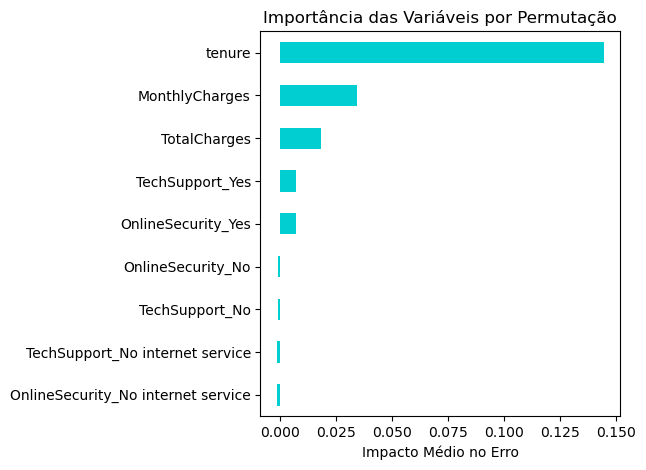

In [23]:
importancias.plot.barh(title="Importância das Variáveis por Permutação",
                       color="darkturquoise")
plt.xlabel("Impacto Médio no Erro")
plt.tight_layout()
plt.show()

100%|██████████| 100/100 [00:01<00:00, 89.03it/s]


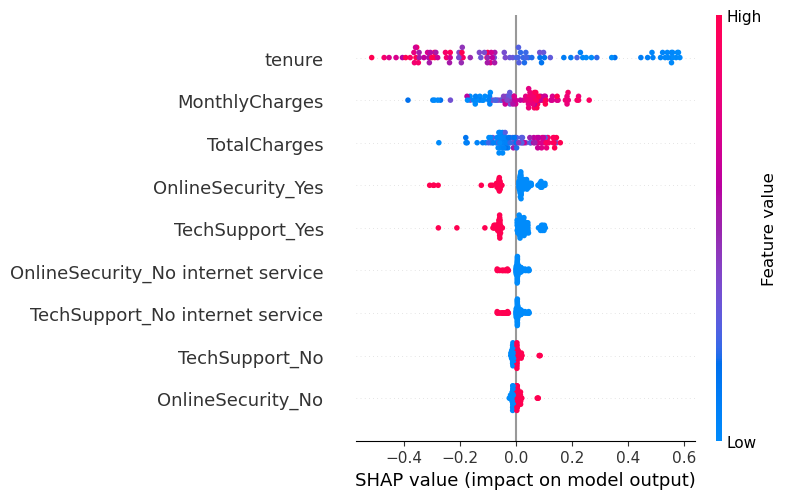

In [24]:
X_amostra = shap.sample(X_treino_tratada, 100, random_state=123)
explainer = shap.KernelExplainer(lr_model.predict, X_amostra)
valores_shap = explainer.shap_values(X_amostra)
shap.summary_plot(valores_shap, X_amostra)

### **7. Utilização do modelo em nova base de dados**

*Serialização dos objetos de "preprocessador" e "lr_model"*

In [25]:
pickle.dump(preprocessador, open("../assets/preprocessador.pkl", 'wb'))
pickle.dump(lr_model, open("../assets/lr_model.pkl", 'wb'))

In [26]:
load_preprocessor = pickle.load(open("../assets/preprocessador.pkl", 'rb'))
load_model = pickle.load(open("../assets/lr_model.pkl", 'rb'))

In [27]:
X_tratada_pkl = load_preprocessor.transform(X_teste) 
X_tratada_pkl = pd.DataFrame(X_tratada_pkl, columns=nomes_variaveis)
X_tratada_pkl.head()

,tenure,MonthlyCharges,TotalCharges,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes
0,-0.796737,-1.148645,-0.842713,1.0,0.0,0.0,1.0,0.0,0.0
1,0.100333,-1.376609,-0.658840,0.0,1.0,0.0,0.0,1.0,0.0
2,-0.592857,-1.508063,-0.875042,0.0,1.0,0.0,0.0,1.0,0.0
3,0.426540,0.355586,0.388956,1.0,0.0,0.0,1.0,0.0,0.0
4,0.752747,-1.464800,-0.559724,0.0,1.0,0.0,0.0,1.0,0.0


In [28]:
load_model.predict(X_tratada_pkl)

array([0, 0, 0, ..., 1, 0, 0], dtype=int64)

In [29]:
load_model.predict_proba(X_tratada_pkl)

array([[0.70094952, 0.29905048],
       [0.96748776, 0.03251224],
       [0.9230174 , 0.0769826 ],
       ...,
       [0.30666343, 0.69333657],
       [0.97698388, 0.02301612],
       [0.9967606 , 0.0032394 ]])